<a href="https://colab.research.google.com/github/nuralfiyanti/PCVK_Ganjil2026/blob/main/PCVKWEEK03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D1. Praktikum Operasi Citra Sederhana

. **1. Buka https://colab.research.google.com/, pilih tab Github dan pastikan repository yang
terpilih ada repository yang sama dengan praktikum pada minggu pertama dan kedua.
Lanjutkan dengan membuat notebook baru dan ubah nama file menjadi “Week3.ipynb”.
Perhatian: Jangan lupa untuk menyimpan salinan ke Github setelah melakukan
perubahan / ketika Anda sudah selesai melakukan praktikum**


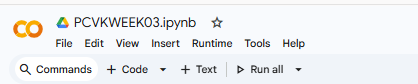

## 0. Setup & Koneksi Google Drive

**2. Akses folder images pada Google Drive Anda dengan kode berikut:**

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**3. Melakukan transformasi linier brightness dengan memasukkan nilai konstanta tertentu
dan menghasilkan warna. Seperti yang telah dibahas pada ulasan teori, formula untuk
melakukan transformasi linier brightness adalah sebagai berikut:

`𝑔(𝑥, 𝑦) = 𝑓(𝑥, 𝑦) + 𝑏`

dimana g(x,y) adalah nilai pixel setelah transformasi, f(x,y) adalah nilai pixel asli, dan b
adalah nilai brightness.

Tuliskan potongan kode berikut untuk mengimplementasikan linier brightness pada
google colab:**

**Transformasi Linier Brightness**

 Mengubah tingkat kecerahan citra 
------------------------------------
Masukkan nilai kecerahan: 30


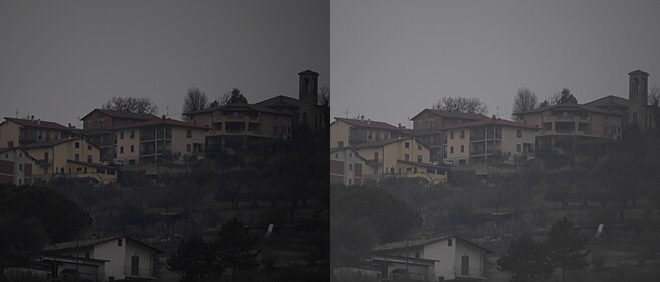

In [63]:
print(' Mengubah tingkat kecerahan citra ')
print('------------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    brightness = 0

original = cv.imread('/content/drive/MyDrive/PCVK/houses.JPG')
brightness_image = np.zeros(original.shape, original.dtype)

# akses per piksel, np.clip melakukan truncate (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

# brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)


## Tugas Praktikum

### 1. Inverse Citra

In [33]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

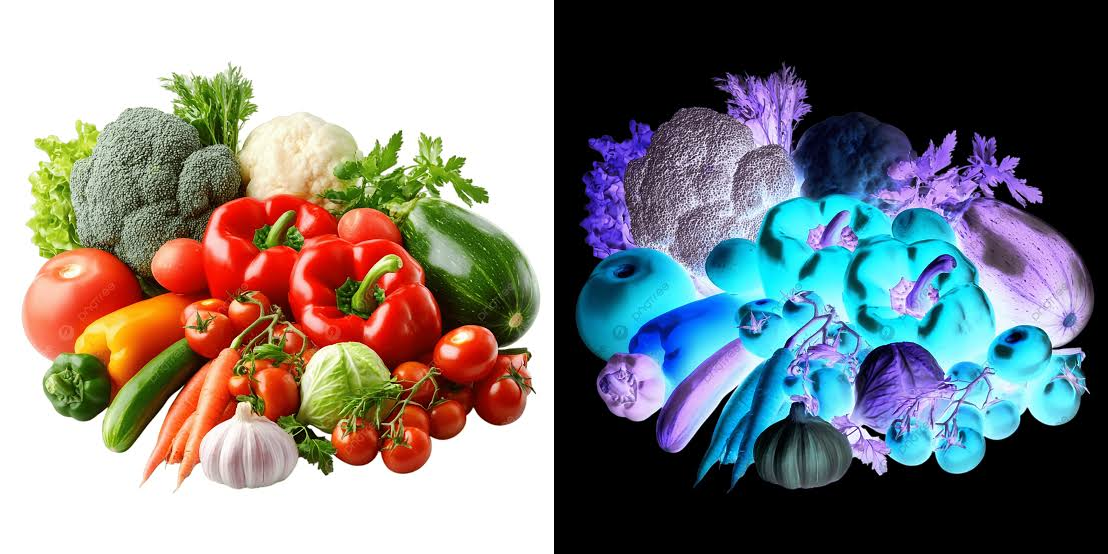

In [14]:
img_bgr = cv.imread('/content/drive/MyDrive/PCVK/buah.jpeg')

# g(x,y) = 255 - f(x,y)
inverse_image = 255 - img_bgr

final_frame = cv.hconcat((img_bgr, inverse_image))
cv2_imshow(final_frame)

**2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan
formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga
menghasilkan keluaran seperti berikut:**

 Mengubah kontras dan tingkat kecerahan citra 
--------------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 100


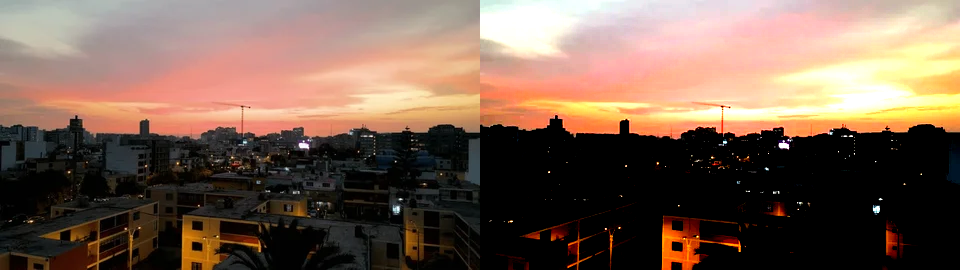

In [15]:
print(' Mengubah kontras dan tingkat kecerahan citra ')
print('--------------------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')
    brightness, contrast = 0, 1.0

original = cv.imread('/content/drive/MyDrive/PCVK/senjaa.webp').astype(np.float64)

# factor = 259*(C+255) / (255*(259-C))
factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

# g(x,y) = factor*(f(x,y)-128) + 128, ditambah brightness, lalu truncate
contrast_image = factor * (original - 128) + 128 + brightness
contrast_image = np.clip(contrast_image, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((original.astype(np.uint8), contrast_image))
cv2_imshow(final_frame)

**3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory
menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi
log, sehingga menghasilkan keluaran seperti berikut:**

 Mengubah tingkat kecerahan citra dengan Transformasi Log 
------------------------------------------------------------
Masukkan nilai kecerahan: 50


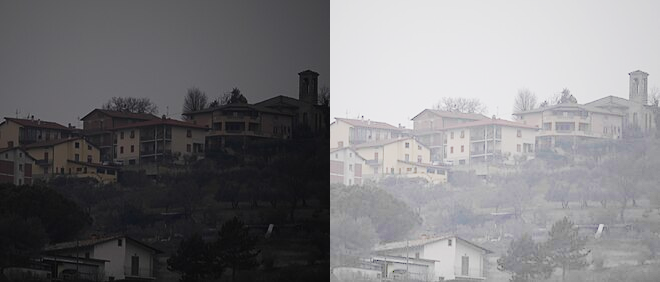

In [16]:
print(' Mengubah tingkat kecerahan citra dengan Transformasi Log ')
print('------------------------------------------------------------')
try:
    c = float(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    c = 50

original = cv.imread('/content/drive/MyDrive/PCVK/houses.JPG').astype(np.float64)

# s = c * log(1 + r)
log_image = c * np.log(1 + original)
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((original.astype(np.uint8), log_image))
cv2_imshow(final_frame)

**4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness,
dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada
bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:**

a. Averaging

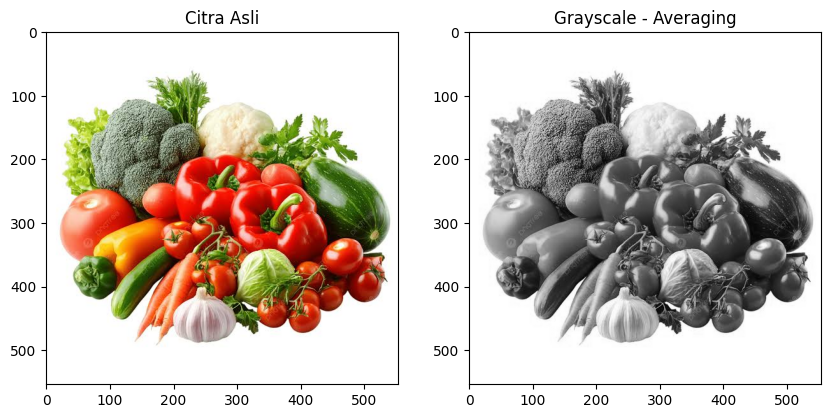

In [17]:
img = cv.imread('/content/drive/MyDrive/PCVK/buah.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB).astype(np.float64)
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

# a. Averaging
gray_avg = ((R + G + B) / 3).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb.astype(np.uint8)); axes[0].set_title('Citra Asli')
axes[1].imshow(gray_avg, cmap='gray'); axes[1].set_title('Grayscale - Averaging')
plt.show()


b. Lightness


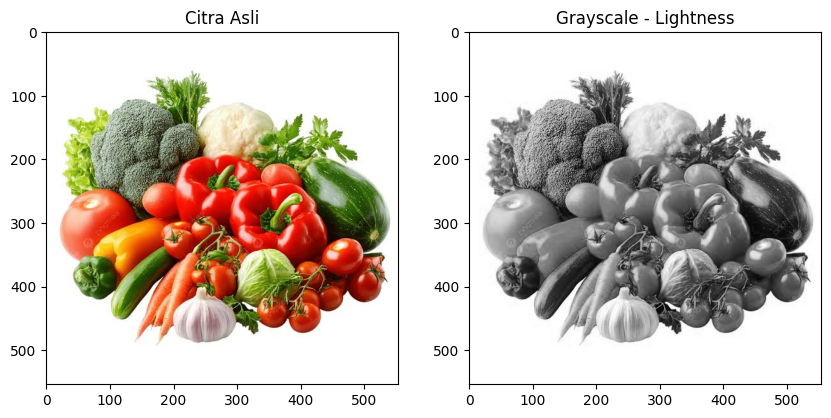

In [18]:
# b. Lightness
gray_lightness = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb.astype(np.uint8)); axes[0].set_title('Citra Asli')
axes[1].imshow(gray_lightness, cmap='gray'); axes[1].set_title('Grayscale - Lightness')
plt.show()

c. Luminance

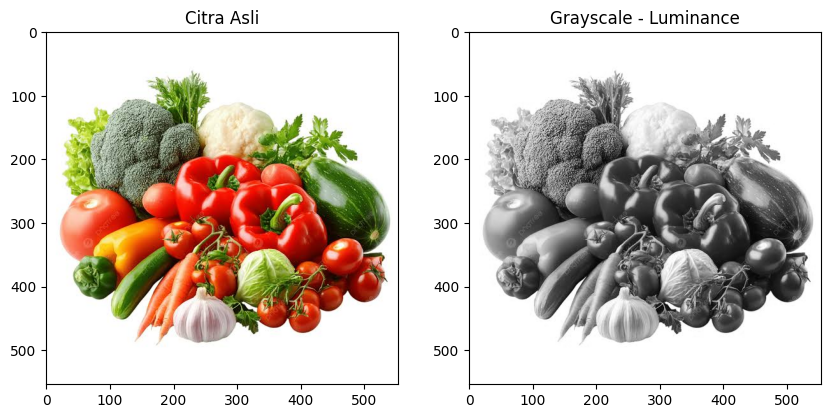

In [19]:
# c. Luminance
gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb.astype(np.uint8)); axes[0].set_title('Citra Asli')
axes[1].imshow(gray_luminance, cmap='gray'); axes[1].set_title('Grayscale - Luminance')
plt.show()

**5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal,
tampilkan warna merah pada citra masukan dan ubah bagian lain yang tidak berwarna
merah menjadi grayscale seperti pada contoh berikut:**

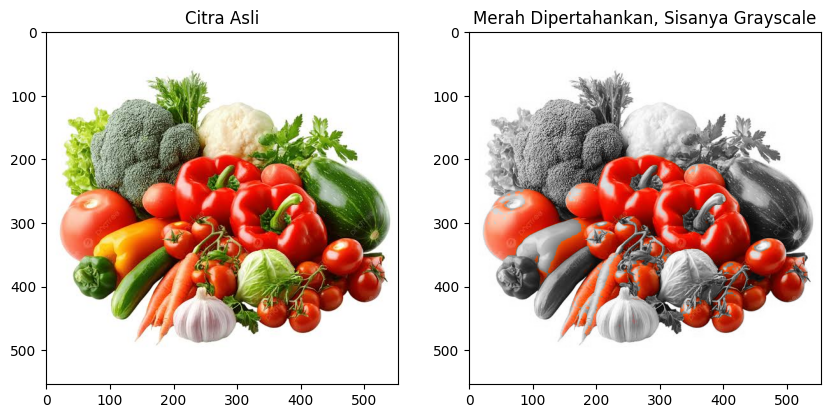

In [20]:
img = cv.imread('/content/drive/MyDrive/PCVK/buah.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

hsv = cv.cvtColor(img_rgb, cv.COLOR_RGB2HSV)

lower_red1, upper_red1 = np.array([0, 70, 50]),   np.array([10, 255, 255])
lower_red2, upper_red2 = np.array([170, 70, 50]), np.array([180, 255, 255])
mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
mask_merah = cv.bitwise_or(mask1, mask2)

gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

hasil = np.where(mask_merah[:, :, None] == 255, img_rgb, gray_3ch)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb); axes[0].set_title('Citra Asli')
axes[1].imshow(hasil); axes[1].set_title('Merah Dipertahankan, Sisanya Grayscale')
plt.show()

**6. Buat Gamma Correction sesuai dengan petunjuk berikut**

Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai
Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk
meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image
dengan gamma correction sesuai rumus yang telah diberikan.

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 2


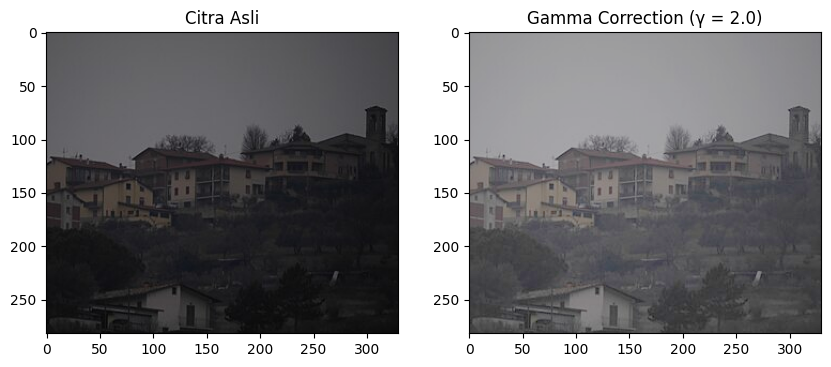

In [21]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 1.0

original = cv.imread('/content/drive/MyDrive/PCVK/houses.JPG')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# I' = 255 * (I/255)^(1/gamma)
normalized = original_rgb / 255.0
gamma_image = np.power(normalized, 1.0 / gamma)
gamma_image = np.clip(gamma_image * 255, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_rgb); axes[0].set_title('Citra Asli')
axes[1].imshow(gamma_image); axes[1].set_title(f'Gamma Correction (γ = {gamma})')
plt.show()

**7. Buat Simulasi Image Dept**

Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit).
Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga
255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0
(000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit.
Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst.
Berikut adalah kode untuk membaca citra masukan dan memberi nilai kedalaman citra,
silahkan lanjutkan kode program berikut sehingga menghasilkan keluaran seperti contoh
pada Gambar.

Masukkan bit depth tujuan (1-8): 3
Bit depth awal   : 8 bit
Bit depth tujuan : 3 bit
Jumlah level     : 8


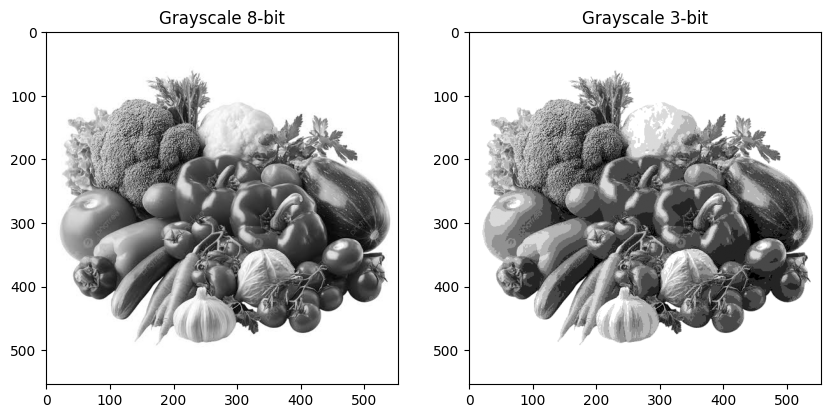

In [22]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, not a number')
    bit_depth = 3

level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/PCVK/buah.jpeg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

# C' = round((C / level) * level)
depth_image = np.round(original / level) * level
depth_image = np.clip(depth_image, 0, 255).astype(np.uint8)

print(f"Bit depth awal   : 8 bit")
print(f"Bit depth tujuan : {bit_depth} bit")
print(f"Jumlah level     : {pow(2, bit_depth)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original, cmap='gray'); axes[0].set_title('Grayscale 8-bit')
axes[1].imshow(depth_image, cmap='gray'); axes[1].set_title(f'Grayscale {bit_depth}-bit')
plt.show()

**8. Buat modul Average Denoising**

Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.
Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg
Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,
gunakan modul glob (import glob).

Sel 1 — baca citra asli & semua citra noise

In [35]:
import zipfile

zip_path = '/content/drive/MyDrive/PCVK/noises-20260920T064916Z-1-001.zip'
extract_path = '/content/noises/noises'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

import os
print(os.listdir(extract_path)[:5])

['noises']


Dengan menggunakan code diatas, anda tinggal memanggil image difolder tersebut
menggunakan cv_img[0], cv_img[1], dst.
Catat hasil PSNR pada tabel berikut. Dari hasil yang sudah anda catat, tuliskan
kesimpulan anda:

In [29]:
PATH_GALAXY = '/content/noises/noises/noises/galaxy.jpg'
print(os.path.exists(PATH_GALAXY))

True


In [37]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from math import log10, sqrt

Jumlah citra noise ditemukan: 101


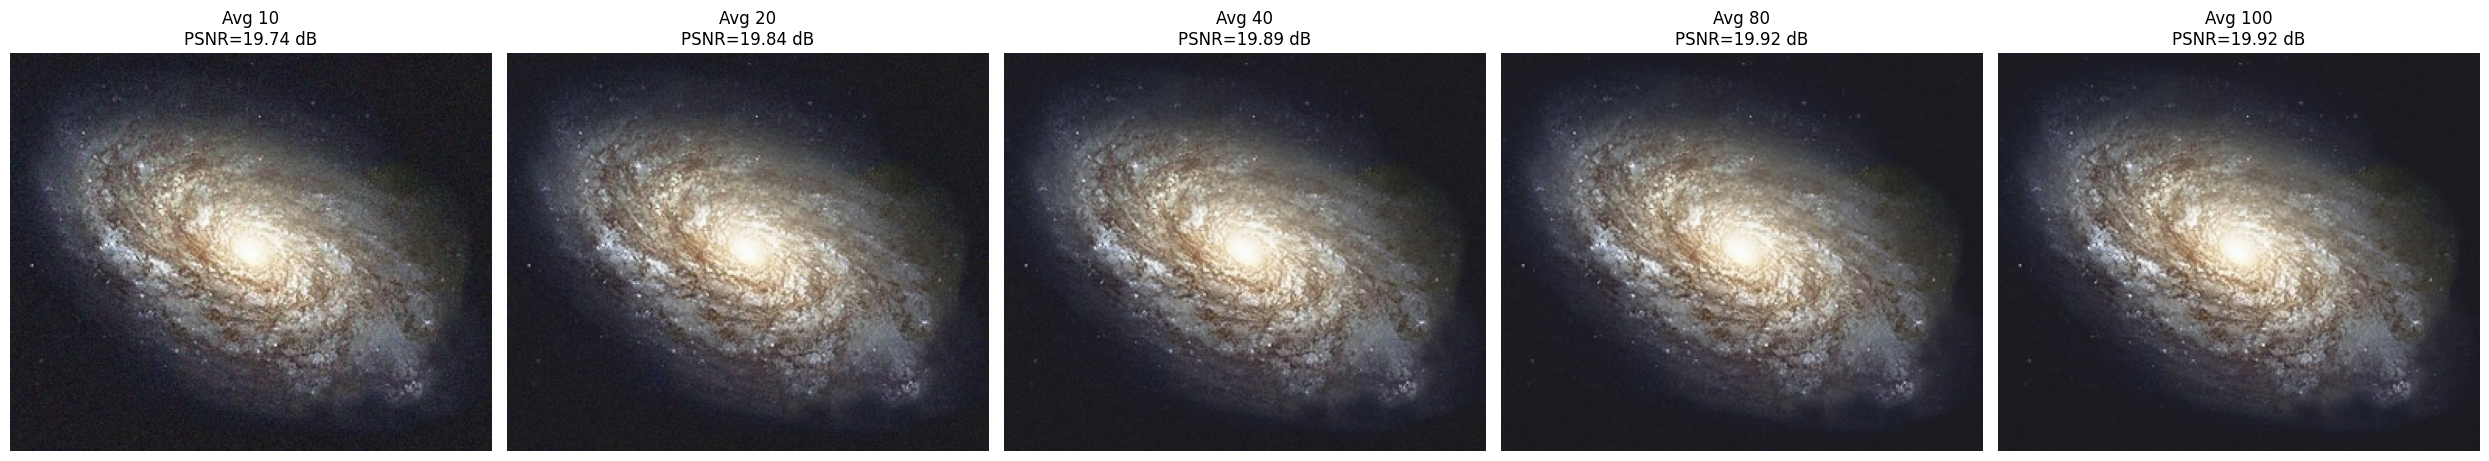

No  Jumlah Citra   Nilai PSNR (dB)     
1   10             19.74               
2   20             19.84               
3   40             19.89               
4   80             19.92               
5   100            19.92               


In [38]:
extract_dir = '/content/noises'

def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    return 20 * log10(255.0 / sqrt(mse))
from math import log10, sqrt

original_galaxy = cv.imread(PATH_GALAXY)

cv_img = []
for img_path in sorted(glob.glob(f'{extract_dir}/**/*.jpg', recursive=True)):
    n = cv.imread(img_path)
    if n is not None:
        cv_img.append(n)

print(f'Jumlah citra noise ditemukan: {len(cv_img)}')

jumlah_list = [10, 20, 40, 80, 100]
hasil_psnr = []

fig, axes = plt.subplots(1, len(jumlah_list), figsize=(5 * len(jumlah_list), 5))

for i, n in enumerate(jumlah_list):
    stack = np.stack(cv_img[:n]).astype(np.float64)
    avg_image = np.mean(stack, axis=0).astype(np.uint8)
    psnr_value = PSNR(original_galaxy, avg_image)
    hasil_psnr.append((n, psnr_value))

    axes[i].imshow(cv.cvtColor(avg_image, cv.COLOR_BGR2RGB))
    axes[i].set_title(f'Avg {n}\nPSNR={psnr_value:.2f} dB')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"{'No':<4}{'Jumlah Citra':<15}{'Nilai PSNR (dB)':<20}")
for i, (n, p) in enumerate(hasil_psnr, start=1):
    print(f"{i:<4}{n:<15}{p:<20.2f}")

In [31]:
import shutil
shutil.copy('/content/noises/noises/noises/galaxy.jpg', '/content/galaxy.jpg')
PATH_GALAXY = '/content/galaxy.jpg'

**Tabel Hasil**

| No | Jumlah Citra di Average | Nilai PSNR (dB) |
|----|--------------------------|------------------|
| 1  | 10                        | 19.74            |
| 2  | 20                        | 19.84            |
| 3  | 40                        | 19.89            |
| 4  | 80                        | 19.92            |
| 5  | 100                       | 19.92            |

**Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?**

Berdasarkan hasil percobaan, peningkatan jumlah citra yang di-average tidak selalu
memberikan kenaikan PSNR yang signifikan. Pada tahap awal, yaitu dari 10 menjadi 20
citra, PSNR memang naik, meskipun hanya sebesar 0,10 dB. Kenaikan tersebut semakin
mengecil pada tahap berikutnya: dari 20 ke 40 citra PSNR hanya naik 0,05 dB, dan dari 40
ke 80 citra naik lebih kecil lagi, yaitu 0,03 dB. Bahkan ketika jumlah citra ditambah dari 80
menjadi 100, nilai PSNR sama sekali tidak berubah (tetap di angka 19,92 dB). Dengan
demikian, dapat disimpulkan bahwa hubungan antara jumlah citra dan peningkatan
kualitas denoising bersifat semakin melambat, bukan meningkat secara linear.

**Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?**

Berdasarkan data yang diperoleh, peningkatan PSNR mulai terlihat tidak signifikan sejak
sekitar 40 citra. Pada rentang 40 hingga 100 citra, kenaikan PSNR yang terjadi sangat kecil
(hanya berkisar 0,00–0,03 dB), sehingga penambahan citra dalam jumlah besar setelah
titik ini tidak lagi memberikan manfaat yang berarti terhadap kualitas hasil denoising.

**Kesimpulan**

Dari percobaan ini dapat disimpulkan bahwa proses averaging terhadap sejumlah citra
yang mengandung noise Gaussian secara acak memang efektif dalam mengurangi noise,
karena noise Gaussian bersifat acak dengan nilai rata-rata mendekati nol, sehingga
semakin banyak citra yang dirata-ratakan, semakin besar pula peluang noise pada
masing-masing citra saling meniadakan satu sama lain. Namun, peningkatan kualitas citra
yang diukur melalui nilai PSNR tidak berbanding lurus dengan penambahan jumlah citra,
melainkan mengikuti pola akar kuadrat (1/√n). Artinya, untuk mengurangi tingkat noise
hingga setengahnya saja, dibutuhkan jumlah citra sekitar empat kali lipat dari sebelumnya.
Konsekuensinya, setelah mencapai jumlah citra tertentu—dalam kasus ini sekitar 40
citra—penambahan jumlah citra lebih lanjut hanya memberikan peningkatan kualitas yang
sangat kecil, sementara beban komputasi dan waktu pemrosesan yang dibutuhkan terus
bertambah. Oleh karena itu, dalam praktiknya, pemilihan jumlah citra untuk proses
averaging perlu mempertimbangkan keseimbangan antara kualitas hasil yang diinginkan
dan efisiensi sumber daya komputasi yang tersedia.

**9. Buat image masking**

Buat image masking untuk image berikut. Image kiri adalah image asli (images/couple.tiff),
sedangkan image paling kanan adalah hasilnya:

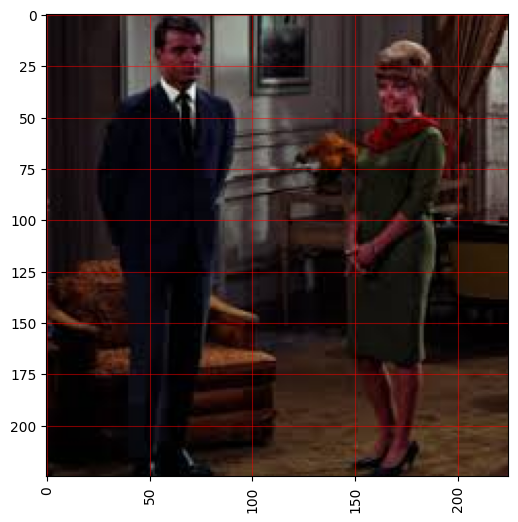

In [49]:
plt.figure(figsize=(10,6))
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.grid(True, color='red', alpha=0.5)
plt.xticks(range(0, w, 50), rotation=90)
plt.yticks(range(0, h, 25))
plt.show()

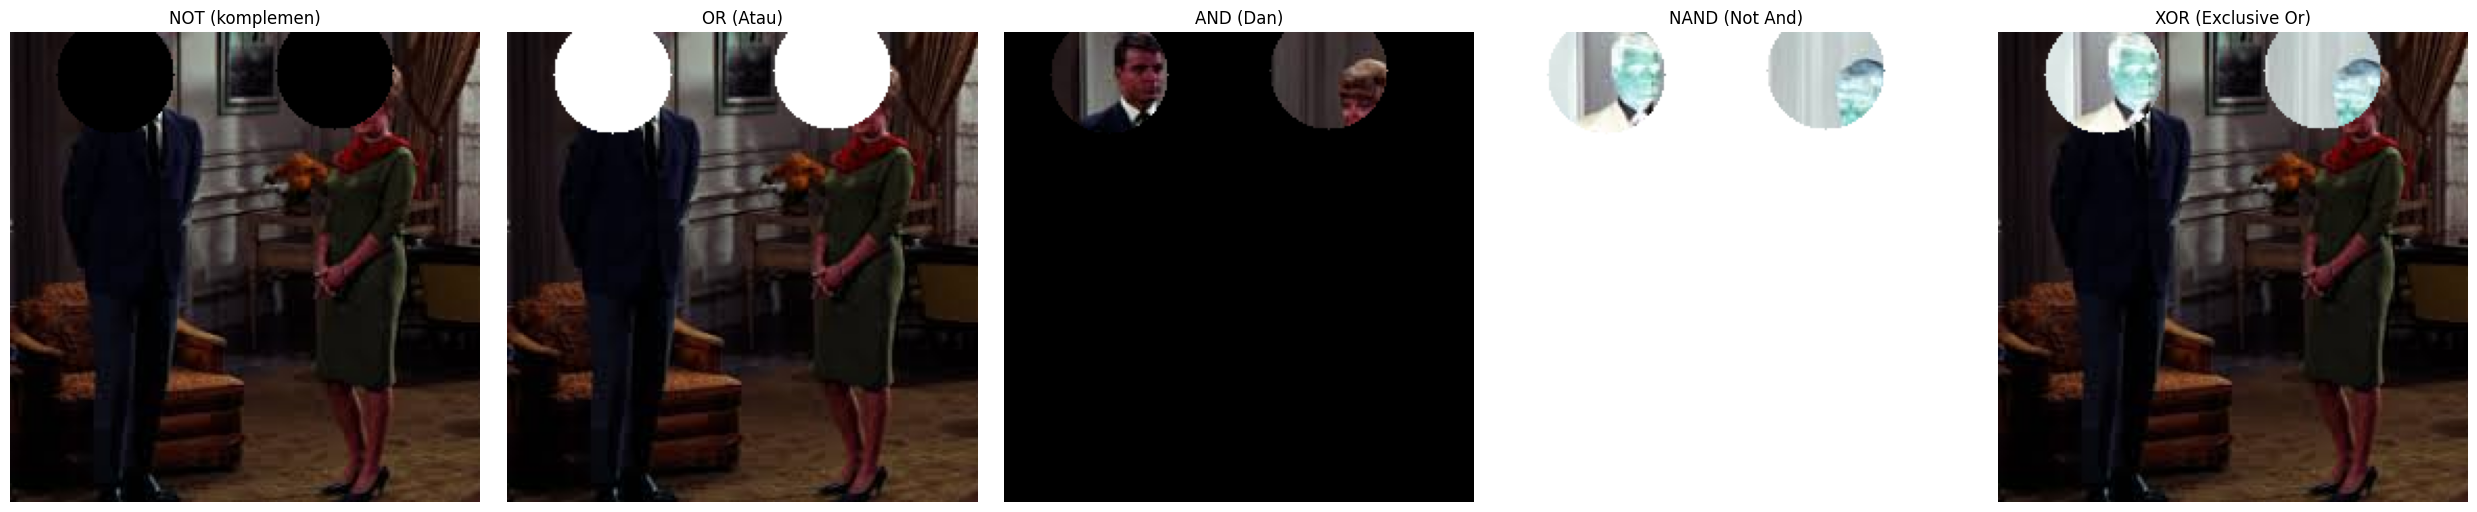

In [64]:
original = cv.imread('/content/drive/MyDrive/PCVK/couple.jpeg')
h, w = original.shape[:2]

mask = np.zeros((h, w), dtype=np.uint8)

# Wajah pria (kiri)
cv.circle(mask, (50, 20), 28, 255, -1)
# Wajah wanita (kanan)
cv.circle(mask, (155, 18), 28, 255, -1)

mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

result_not  = cv.bitwise_and(original, cv.bitwise_not(mask_3ch))
result_or   = cv.bitwise_or(original, mask_3ch)
result_and  = cv.bitwise_and(original, mask_3ch)
result_nand = cv.bitwise_not(cv.bitwise_and(original, mask_3ch))
result_xor  = cv.bitwise_xor(original, mask_3ch)

results = {
    'NOT (komplemen)': result_not,
    'OR (Atau)': result_or,
    'AND (Dan)': result_and,
    'NAND (Not And)': result_nand,
    'XOR (Exclusive Or)': result_xor,
}

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, (nama_operator, img_hasil) in enumerate(results.items()):
    axes[i].imshow(cv.cvtColor(img_hasil, cv.COLOR_BGR2RGB))
    axes[i].set_title(nama_operator)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Kelima operator logika menghasilkan citra yang berbeda karena masing-masing memproses nilai piksel mask (0 atau 255) dengan cara yang berbeda terhadap citra asli. Pada operator AND, hanya area yang bernilai 255 pada mask (yaitu area wajah) yang menampilkan citra asli, sedangkan area lain (nilai 0) menjadi hitam, karena operasi AND dengan 0 selalu menghasilkan 0. Pada operator OR, area mask (255) langsung menjadi putih penuh karena OR dengan 255 selalu menghasilkan 255, sedangkan area lain tetap menampilkan citra asli karena OR dengan 0 tidak mengubah nilai piksel.

Operator NOT diterapkan dengan cara membalik nilai mask terlebih dahulu, lalu di-AND-kan dengan citra asli, sehingga hasilnya berkebalikan dengan AND — area wajah menjadi hitam, sedangkan area lain tetap menampilkan citra asli. Operator NAND merupakan kebalikan dari AND, sehingga area wajah menampilkan warna yang terbalik (invers) dari citra asli, sedangkan area lain yang tadinya bernilai 0 menjadi putih (255), karena NOT dari 0 adalah 255. Terakhir, operator XOR hanya membalik nilai piksel pada area mask (255), sedangkan area lain (nilai 0) tidak berubah karena XOR dengan 0 sama dengan nilai aslinya.

**10. Foto Malam Hari**

Carilah foto malam hari yang gelap. Namun, beberapa bagian gambar memiliki detail yang
sebenarnya cukup baik. Pilih salah satu metode berikut dan implementasikan pada foto
tersebut (Linear Brightness, Contrast, Logarithmic Brightness, Gamma Correction). Sebutkan
alasan dan resiko metode yang Anda gunakan.

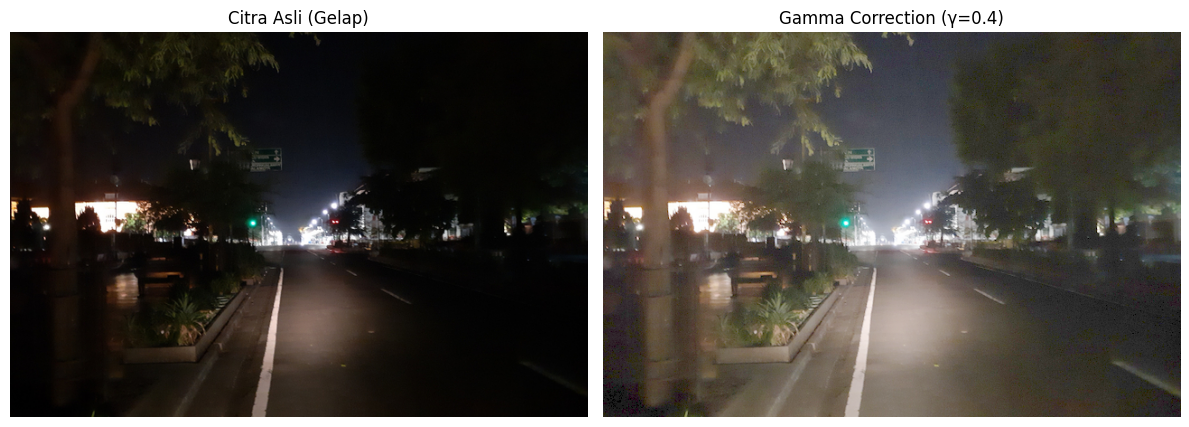

In [55]:
original = cv.imread('/content/drive/MyDrive/PCVK/malam.jpg')
gamma = 0.4  # <1 = mencerahkan bagian gelap; coba-coba 0.3–0.6
gamma_corrected = np.power(original / 255.0, gamma) * 255.0
gamma_corrected = np.uint8(np.clip(gamma_corrected, 0, 255))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
axes[0].set_title('Citra Asli (Gelap)')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(gamma_corrected, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma Correction (γ={gamma})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Saya memilih metode Gamma Correction dengan γ = 0.4 karena foto memiliki rentang dinamis yang lebar — sebagian besar area (jalan, trotoar, pepohonan) sangat gelap, sementara area di sekitar lampu jalan sudah cukup terang. Gamma correction bersifat non-linear, sehingga mampu menaikkan detail pada area gelap secara signifikan tanpa membuat area yang sudah terang menjadi over-exposed secara ekstrem, berbeda dengan Linear Brightness yang menambahkan nilai secara merata ke seluruh piksel dan berisiko membuat area terang langsung ter-truncate ke 255.

Risiko yang muncul dari metode ini adalah: (1) noise yang sebelumnya tersembunyi di area sangat gelap ikut terangkat dan menjadi lebih terlihat, terutama di area langit malam; (2) area yang sudah terang di sekitar lampu jalan menjadi sedikit pudar/overexposed karena kurva gamma tetap menaikkan nilai piksel di rentang menengah-tinggi, meski tidak seagresif area gelap.

**11. Buka gambar crayfish.jpg pada folder Images.**

Perbaiki kualitas pada citra tersebut dengan metode operasi dasar citra apapun.
Diperbolehkan menggunakan lebih dari 1 metode. Kemudian jelaskan:
• Metode yang dipilih
• Alasan pemilihan
• Menentukan parameter terbaik
• Menghasilkan citra dengan menunjukkan before-after.

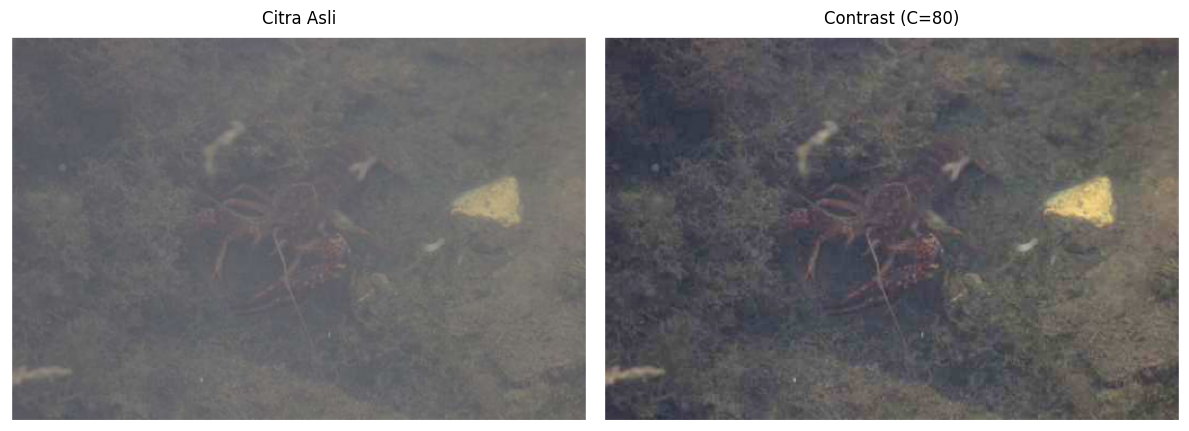

Std deviasi asli: 25.98122808488509
Std deviasi setelah contrast: 32.38893074133656


In [62]:
original = cv.imread('/content/drive/MyDrive/PCVK/crayfish.png')

# Contrast Transformation
contrast = 80
factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

contrast_image = factor * (original.astype(np.float32) - 128) + 128
contrast_image = np.uint8(np.clip(contrast_image, 0, 255))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
axes[0].set_title('Citra Asli')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(contrast_image, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Contrast (C={contrast})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("Std deviasi asli:", np.std(original))
print("Std deviasi setelah contrast:", np.std(contrast_image))

**Metode yang dipilih:**
Contrast Transformation.

**Alasan pemilihan:**
Citra crayfish.jpg merupakan foto bawah air (underwater) yang memiliki karakteristik kontras rendah akibat cahaya yang tersebar oleh partikel-partikel di dalam air (kekeruhan/turbidity), bukan karena kekurangan pencahayaan. Oleh karena itu, metode Contrast Transformation dipilih karena mampu memperlebar rentang intensitas warna sehingga objek crayfish lebih mudah dibedakan dari background pasir/lumut di sekitarnya.

Sebagai perbandingan, sempat dicoba juga kombinasi Contrast dengan Gamma Correction (γ=0.5), namun hasilnya justru menurunkan kontras yang sudah didapat karena gamma mencerahkan seluruh piksel termasuk area kabur akibat kekeruhan air, sehingga citra kembali terlihat pudar. Oleh karena itu, Gamma Correction tidak digunakan dan Contrast Transformation dipilih sebagai solusi akhir.

**Menentukan parameter terbaik:**
Dilakukan eksperimen pada beberapa nilai contrast (C). Pada C = 40, peningkatan kontras masih terlalu halus dan perbedaan dengan citra asli belum terlihat jelas. Setelah dinaikkan ke C = 80, objek crayfish (warna merah) dan batu kuning menjadi lebih tegas dan mudah dibedakan dari background, tanpa membuat warna menjadi terlalu ekstrem/pecah. Nilai C = 80 dipilih sebagai parameter terbaik.